# Exercises

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.stats.power as smp
import statsmodels.stats.proportion as smprop
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

---
## Exercise 2.16 — Sample distributions

### a)
Verify by simulation that $\frac{n_1+n_2-2}{\sigma^2} S^2_p \sim \chi^2(n_1 + n_2 - 2)$.

You may use $n_1 = 5$, $n_2 = 8$, $\mu_1 = 2$, $\mu_2 = 4$, and $\sigma^2 = 2$.

**Solution:**

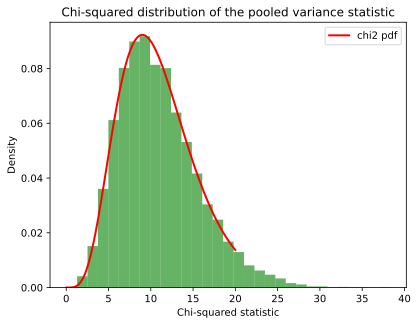

In [2]:
n1, n2 = 5, 8
mu1, mu2 = 2, 4
sigma2 = 2
sim_amount = 10000

chi2_stats = np.zeros(sim_amount)

for i in range(sim_amount):
    X = stats.norm.rvs(loc=mu1, scale=np.sqrt(sigma2), size=n1)
    Y = stats.norm.rvs(loc=mu2, scale=np.sqrt(sigma2), size=n2)

    S1_sq = np.var(X, ddof=1)
    S2_sq = np.var(Y, ddof=1)

    Sp_sq = ((n1-1)*S1_sq + (n2-1)*S2_sq) / (n1+n2-2)

    chi2_stats[i] = (n1+n2-2)*Sp_sq/sigma2

plt.hist(chi2_stats, bins=30, density=True, alpha=0.6, color='g')
x = np.linspace(0, 20, 100)
plt.plot(x, stats.chi2.pdf(x, df=n1+n2-2), 'r-', lw=2, label='chi2 pdf')
plt.title('Chi-squared distribution of the pooled variance statistic')
plt.xlabel('Chi-squared statistic')
plt.ylabel('Density')
plt.legend()
plt.show()

### b)
Show that if $X \sim N(\mu_1, \sigma^2)$ and $Y \sim N(\mu_2, \sigma^2)$, then
$$\frac{\bar{X} - \bar{Y} - (\mu_1 - \mu_2)}{S_p \sqrt{\frac{1}{n_1} + \frac{1}{n_2}}} \sim t(n_1 + n_2 - 2)$$
Verify the result by simulation. You may use $n_1 = 5$, $n_2 = 8$, $\mu_1 = 2$, $\mu_2 = 4$, and $\sigma^2 = 2$.

**Solution:**

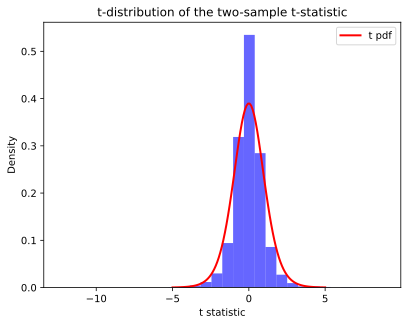

In [3]:
t_stats = np.zeros(sim_amount)

for i in range(sim_amount):
    X = stats.norm.rvs(loc=mu1, scale=np.sqrt(sigma2), size=n1)
    Y = stats.norm.rvs(loc=mu2, scale=np.sqrt(sigma2), size=n2)

    S1_sq = np.var(X, ddof=1)
    S2_sq = np.var(Y, ddof=1)

    Sp_sq = ((n1-1)*S1_sq + (n2-1)*S2_sq) / (n1+n2-2)

    t_stats[i] = (X.mean() - Y.mean() - (mu1 - mu2)) / (Sp_sq * (np.sqrt((1/n1 + 1/n2))))

plt.hist(t_stats, bins=30, density=True, alpha=0.6, color='b')
x = np.linspace(-5, 5, 100)
plt.plot(x, stats.t.pdf(x, df=n1+n2-2), 'r-', lw=2, label='t pdf')
plt.title('t-distribution of the two-sample t-statistic')
plt.xlabel('t statistic')
plt.ylabel('Density')
plt.legend()
plt.show()

---
## Exercise 2.17 — Sample distributions 2

Let $X_1, \ldots, X_n$ and $Y_1, \ldots, Y_n$, with $X_i \sim N(\mu_1, \sigma^2)$ and $Y_i \sim N(\mu_2, \sigma^2)$ be independent random variables. Hence, two samples before they are taken. $S^2_1$ and $S^2_2$ are the sample variances based on the $X$'s and the $Y$'s respectively. Now define a new random variable
$$Q = \frac{S^2_1}{S^2_2}$$

### a)
For $n$ equal 2, 4, 8, 16 and 32 find:
1. $P(Q < 1)$
2. $P(Q > 2)$
3. $P\left(Q < \frac{1}{2}\right)$
4. $P\left(\frac{1}{2} < Q < 2\right)$

**Solution:**

In [8]:
n_arr = np.array([2,4,8,16,32])

for n in n_arr:
    df = n - 1
    print(f"n={n}:")
    print(f"  P(Q < 1)       = {stats.f.cdf(1,   df, df):.4f}")
    print(f"  P(Q > 2)       = {1 - stats.f.cdf(2,   df, df):.4f}")
    print(f"  P(Q < 1/2)     = {stats.f.cdf(0.5, df, df):.4f}")
    print(f"  P(1/2 < Q < 2) = {stats.f.cdf(2,   df, df) - stats.f.cdf(0.5, df, df):.4f}")

n=2:
  P(Q < 1)       = 0.5000
  P(Q > 2)       = 0.3918
  P(Q < 1/2)     = 0.3918
  P(1/2 < Q < 2) = 0.2163
n=4:
  P(Q < 1)       = 0.5000
  P(Q > 2)       = 0.2918
  P(Q < 1/2)     = 0.2918
  P(1/2 < Q < 2) = 0.4164
n=8:
  P(Q < 1)       = 0.5000
  P(Q > 2)       = 0.1904
  P(Q < 1/2)     = 0.1904
  P(1/2 < Q < 2) = 0.6193
n=16:
  P(Q < 1)       = 0.5000
  P(Q > 2)       = 0.0955
  P(Q < 1/2)     = 0.0955
  P(1/2 < Q < 2) = 0.8089
n=32:
  P(Q < 1)       = 0.5000
  P(Q > 2)       = 0.0290
  P(Q < 1/2)     = 0.0290
  P(1/2 < Q < 2) = 0.9420


### b)
For at least one value of $n$ illustrate the results above by direct simulation from independent normal distributions. You may use any values of $\mu_1$, $\mu_2$ and $\sigma^2$.

**Solution:**

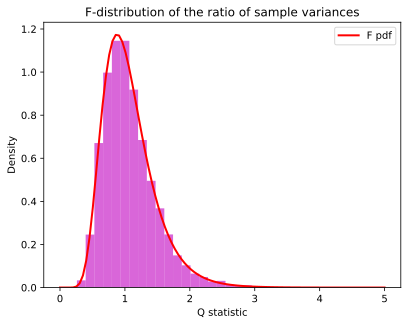

In [11]:
n = 32
Q_stats = np.zeros(sim_amount)

for i in range(sim_amount):
    X = stats.norm.rvs(size=n)
    Y = stats.norm.rvs(size=n)

    S1_sq = np.var(X, ddof=1)
    S2_sq = np.var(Y, ddof=1)

    Q_stats[i] = S1_sq / S2_sq

plt.hist(Q_stats, bins=30, density=True, alpha=0.6, color='m')
x = np.linspace(0, 5, 100)
plt.plot(x, stats.f.pdf(x, dfn=n-1, dfd=n-1), 'r-', lw=2, label='F pdf')
plt.title('F-distribution of the ratio of sample variances')
plt.xlabel('Q statistic')
plt.ylabel('Density')
plt.legend()
plt.show()